In [1]:

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

import healpy as hp

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import LambdaCDM

In [2]:
# Set default font size
mpl.rcParams['font.size'] = 12

### Process the Neronov-Semikoz catalog

In [3]:
# load NS catalog
ns_catalog = pd.read_csv("./galcats/ns/NS_total.csv", index_col=0)

In [4]:
ns_catalog = ns_catalog[ns_catalog["z"] < 0.51]
ns_catalog.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table
2,RX J0022.0+0006,5.515,0.113,5,9,1,1.66±0.12,0.306,BLL,NaN,2
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1
5,PMN J0039-2220,9.778,-22.328,1,4,1,1.78±0.09,0.064,BLL,NaN,3
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1
8,1RXS J005117.7-624154,12.824,-62.704,2,5,1,1.77±0.02,0.156,BLL,NaN,2


In [27]:
MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg').galactic
theta_MW, phi_MW = np.pi/2 - MW_plane.b.rad, MW_plane.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg').galactic
theta_EQ, phi_EQ = np.pi/2 - EQ_plane.b.rad, EQ_plane.l.rad

SG_plane = SkyCoord(sgl=np.linspace(0, 360, 100), sgb=0, frame='supergalactic', unit='deg').galactic
theta_SG, phi_SG = np.pi/2 - SG_plane.b.rad, SG_plane.l.rad

### Load LSS maps

In [ ]:
import os
from scipy.interpolate import RegularGridInterpolator

ovd_files = os.listdir('./overdensity')
z_start, z_end = [float(f[4:7])/100 for f in ovd_files], [float(f[8:11])/100 for f in ovd_files]

zbins = z_start.copy()
zbins.append(z_end[-1])

maps_d = np.array([np.load(f"./overdensity/{f}") for f in ovd_files])
maps = np.zeros([maps_d.shape[0] + 2, maps_d.shape[1]])
maps[1:-1] = maps_d

z_data = np.zeros(len(z_start)+2)
z_data[1:-1] = 0.5 * (np.array(z_start) + np.array(z_end))
z_data[-1] = 0.5
### extend grid with zero maps @ z = 0.0 and z = 0.5

nside = hp.get_nside(maps[0])
npix = hp.get_map_size(maps[0])
pix_data = np.arange(0, npix, 1)

zp_interpolator = RegularGridInterpolator(
    (z_data, pix_data),
    maps,
    bounds_error=False,
    fill_value=0
)

In [10]:
z_grid = np.linspace(0, 0.7, 140)

zpx, pxz = np.meshgrid(z_grid, pix_data, indexing='ij')

maps_interp = zp_interpolator((zpx, pxz))

#### make a movie

In [11]:
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import healpy as hp

# # Initialize a clean figure
# fig = plt.figure()

# def update(i):
#     # 1. Clear the figure so titles, maps, and colorbars don't overlap
#     plt.clf() 
    
#     # 2. Draw the map for the current frame
#     hp.mollview(
#         maps_interp[i], 
#         title=f"z = {z_grid[i]:.4f}", 
#         min=-2, 
#         max=2, 
#         cmap='coolwarm', 
#         coord=['C', 'G'],
#         hold=True  # Tells healpy to use the existing figure instead of creating a new window
#     )

# # Create the animation using FuncAnimation
# ani = animation.FuncAnimation(
#     fig, 
#     update, 
#     frames=len(z_grid), 
#     interval=50, 
#     repeat_delay=1000
# )

# writer = animation.FFMpegWriter(
#     fps=5, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("./figures/movie.mp4", writer=writer)

# # To display it in a Jupyter Notebook, you can uncomment the line below:
# from IPython.display import HTML
# HTML(ani.to_jshtml())

### LOS interpolation

In [12]:
ns_catalog = ns_catalog.sort_values(by="z")

pixs = hp.ang2pix(nside, theta=np.pi/2 - np.deg2rad(ns_catalog["Dec"]), phi=np.deg2rad(ns_catalog["RA"]))

zpx_ns, pxz_ns = np.meshgrid(z_grid, pixs, indexing='ij')
weights = zpx_ns < np.array(ns_catalog["z"])
values = zp_interpolator((zpx_ns, pxz_ns)) * weights

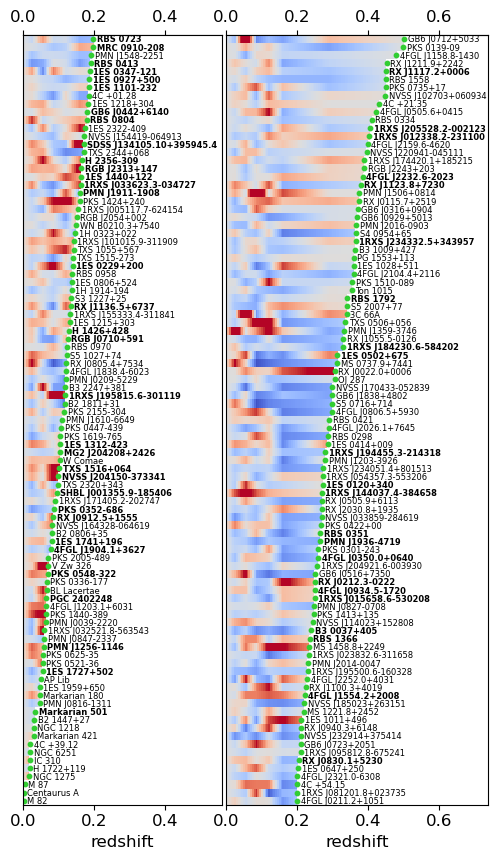

In [13]:
fig = plt.figure(figsize=(6, 10))
gs = GridSpec(1, 2, width_ratios=[56, 74], figure=fig, wspace=0.02)

ax = plt.subplot(gs[0])
ax.pcolormesh(z_grid, np.arange(0, 190), values.T, cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)
ax.pcolormesh(z_grid, np.arange(0, 190), weights.T, alpha=~weights.T, cmap='Grays', vmin=0, vmax=1, rasterized=True)
ax.scatter(ns_catalog["z"], np.arange(0, 190), s=10, color='limegreen')
for i, ind in enumerate(ns_catalog.index):
    if i > 94:
        continue
    weight = "bold" if ns_catalog["HSP"][ind] == "E" else "normal"
    ax.text(ns_catalog["z"][ind] + 0.01, i-0.45, ns_catalog["4FGL"][ind], fontsize=6, rotation=0,
            weight=weight)
ax2 = ax.secondary_xaxis(location='top')

ax.set_yticks([])
ax.set_ylim([-0.5, 94.5])
ax.set_xlim([0, 0.56])
ax.set_xlabel("redshift")

ax = plt.subplot(gs[1])
ax.pcolormesh(z_grid, np.arange(0, 190), values.T, cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)
ax.pcolormesh(z_grid, np.arange(0, 190), weights.T, alpha=~weights.T, cmap='Grays', vmin=0, vmax=1, rasterized=True)
ax.scatter(ns_catalog["z"], np.arange(0, 190), s=10, color='limegreen')
for i, ind in enumerate(ns_catalog.index):
    if i < 95:
        continue
    weight = "bold" if ns_catalog["HSP"][ind] == "E" else "normal"
    ax.text(ns_catalog["z"][ind] + 0.01, i-0.45, ns_catalog["4FGL"][ind], fontsize=6, rotation=0,
            weight=weight)
ax2 = ax.secondary_xaxis(location='top')

ax.set_yticks([])
ax.set_ylim([94.5, 189.5])
ax.set_xlim([0, 0.74])
ax.set_xlabel("redshift")

plt.savefig("./figures/lss-ns-zsorted_v.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [14]:
ns_catalog["ovdvalue"] = np.trapz(values, z_grid, axis=0) / ns_catalog["z"]

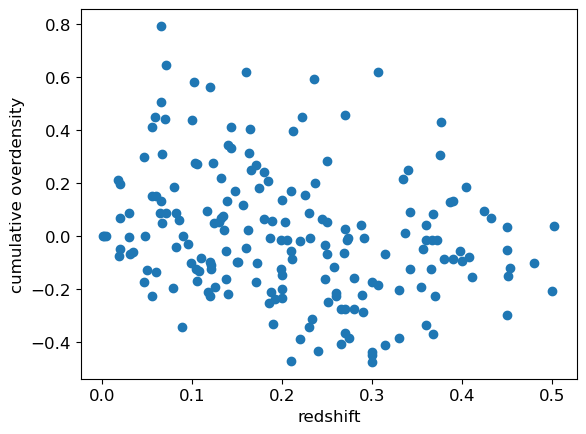

In [15]:
plt.scatter(ns_catalog["z"], ns_catalog["ovdvalue"])
plt.xlabel("redshift")
plt.ylabel("cumulative overdensity")
plt.show()

In [16]:
ns_extr = ns_catalog.query('HSP == "E"')
ns_extr.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
157,Markarian 501,253.474,39.759,81,109,22,1.795±0.008,0.034,BLL,E,0,-0.059566
162,1ES 1727+502,262.078,50.227,5,11,4,1.785±0.022,0.055,BLL,E,0,-0.224950
169,PMN J1256-1146,194.063,-11.776,2,2,0,1.97±0.05,0.058,BLL,E,3,0.449762
68,PGC 2402248,113.362,51.880,3,5,1,1.769±0.079,0.065,BLL,E,0,0.131716
53,PKS 0548-322,87.625,-32.277,4,5,0,1.829±0.071,0.069,BLL,E,0,0.440489


In [17]:
ns_lowz = ns_catalog.query('z < 0.18')
ns_lowz.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.212933
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.076245


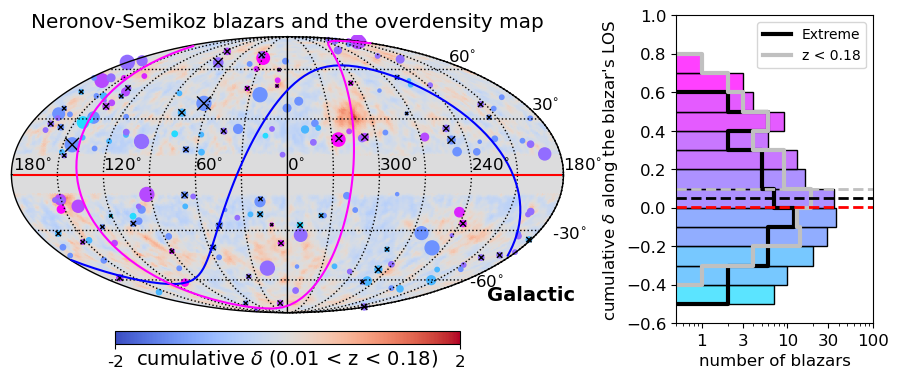

In [42]:
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(1, 2, figure=fig, width_ratios=[7, 2], wspace=0.1)
ax =  fig.add_subplot(gs[0])
plt.sca(ax)
hp.mollview(np.average(np.array(maps)[:-1], axis=0), coord=['C', 'G'], cmap='coolwarm',
            title="Neronov-Semikoz blazars and the overdensity map",
            min=-2, max=2, cbar=True,
            unit=r'cumulative $\delta$ (0.01 < z < 0.18)',
            notext=False, sub=None, hold=True, margins=[0, -0.10, 0, 0.05])

hp.graticule(color='black')

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='G')
hp.projplot(theta_SG, phi_SG, color='magenta', coord='G')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

size = np.clip(5 * ns_catalog["N_100"], a_min=0.0, a_max=100.0)

# ALL BLAZARS
cmap = plt.get_cmap("cool", lut=8)
p = hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), np.deg2rad(ns_catalog["RA"]), coord='C',
               s=size, c=ns_catalog['ovdvalue'], cmap=cmap, vmin=-0.8, vmax=0.8)
# plt.colorbar(p)

# EXTREME
size = np.clip(5 * ns_extr["N_100"], a_min=0.0, a_max=100.0)
hp.projscatter(np.pi/2 - np.deg2rad(ns_extr["Dec"]), np.deg2rad(ns_extr["RA"]), coord='C',
               marker='x', s=size, color='black', linewidth=1.0)

ax2 = fig.add_subplot(gs[1])
plt.sca(ax2)

bs = np.arange(-1.0, 2.4, 0.1)
for x in bs:
    cat_x = ns_catalog.query("@x <= ovdvalue <= @x + 0.1")["ovdvalue"]
    x_c = ((x+0.1) / 1.6) + 0.5
    sns.histplot(y=cat_x, bins=[x, x+0.1], ax=ax2, color=cmap(x_c))
    
sns.histplot(y=ns_extr["ovdvalue"], bins=bs, alpha=1.0,
             ax=ax2, fill=False, color='black', linewidth=3, element='step',
             label='Extreme')

sns.histplot(y=ns_lowz["ovdvalue"], bins=bs, alpha=1.0,
             ax=ax2, fill=False, color='silver', linewidth=3, element='step',
             label='z < 0.18')

ax2.hlines([np.average(ns_catalog["ovdvalue"]), np.average(ns_extr["ovdvalue"]), np.average(ns_lowz['ovdvalue'])], 0.5, 100,
           colors=['red', 'black', 'silver'], linewidth=2, linestyle='dashed')

ax2.legend(loc=1, fontsize=10)

ax2.set_xlabel("number of blazars")
ax2.set_xscale('log')
ax2.set_xticks([1, 3, 10, 30, 100], [1, 3, 10, 30, 100])
ax2.set_xlim(0.5, 100)

ax2.set_ylabel(r"cumulative $\delta$ along the blazar's LOS")
ax2.set_yticks(np.arange(-1.6, 2.21, 0.2))
ax2.set_ylim(-0.6, 1.0)

plt.savefig("./figures/lss-ns-blazars.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [95]:
ns_catalog.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.212933
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.076245


In [96]:
# ns_catalog.to_csv("./galcats/ns/ns_total_ovd.csv")

In [97]:
ns_extr = ns_extr.sort_values(by="ovdvalue")
ns_extr[ns_extr["Table"] == 0]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
31,RBS 0413,49.972,18.753,3,7,1,1.709±0.054,0.190,BLL,E,0,-0.331720
162,1ES 1727+502,262.078,50.227,5,11,4,1.785±0.022,0.055,BLL,E,0,-0.224950
62,RGB J0710+591,107.623,59.135,3,4,1,1.703±0.043,0.125,BLL,E,0,-0.191931
181,MG2 J204208+2426,310.536,24.458,4,5,1,1.947±0.052,0.104,BLL,E,0,-0.121899
45,1ES 0502+675,76.996,67.622,25,34,6,1.589±0.02,0.314,BLL,E,0,-0.066199
157,Markarian 501,253.474,39.759,81,109,22,1.795±0.008,0.034,BLL,E,0,-0.059566
76,MRC 0910-208,138.227,-21.045,6,11,1,1.816±0.038,0.198,BLL,E,0,-0.014045
87,1ES 1101-232,165.909,-23.496,1,6,1,1.699±0.06,0.186,BLL,E,0,-0.007507
138,H 1426+428,217.129,42.678,9,11,4,1.659±0.038,0.129,BLL,E,0,0.053527
36,1ES 0347-121,57.354,-11.994,3,3,1,1.854±0.063,0.188,BLL,E,0,0.057297


In [98]:
ns_extr[ns_extr["Table"] == 1]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1,-0.123101
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1,-0.029226
20,1ES 1440+122,220.698,12.013,1,4,0,1.76±0.05,0.163,BLL,E,1,0.313621


In [99]:
ns_extr[ns_extr["Table"] == 2]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
250,PMN J1936-4719,294.242,-47.340,3,3,0,1.82±0.05,0.265,BLL,E,2,-0.404689
79,PKS 0352-686,58.274,-68.528,2,5,0,1.67±0.07,0.088,BLL,E,2,-0.341587
47,RBS 0351,41.158,-58.326,5,6,0,1.72±0.04,0.265,BLL,E,2,-0.275812
251,1RXS J194455.3-214318,296.229,-21.722,3,6,0,1.84±0.04,0.280,BLL,E,2,-0.272948
75,4FGL J0350.0+0640,57.504,6.675,3,3,0,1.47±0.18,0.260,BCU,E,2,-0.214753
235,1RXS J184230.6-584202,280.611,-58.680,2,3,0,1.73±0.09,0.330,BLL,E,2,-0.202025
239,4FGL J1904.1+3627,286.034,36.453,3,4,0,1.85±0.06,0.078,BLL,E,2,-0.195825
265,RBS 1792,328.282,-0.693,3,3,0,1.86±0.12,0.342,BLL,E,2,-0.124925
261,1RXS J205528.2-002123,313.853,-0.340,3,3,1,1.8±0.07,0.407,BLL,E,2,-0.078245
242,PMN J1911-1908,287.868,-19.149,2,4,0,1.87±0.07,0.160,BLL,E,2,-0.046155


In [100]:
ns_extr[ns_extr["Table"] == 3]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
10,B3 0037+405,10.099,40.836,1,3,1,1.88±0.11,0.240,BLL,E,3,-0.431040
120,1ES 0927+500,142.625,49.858,2,2,0,1.85±0.13,0.187,BLL,E,3,-0.209085
151,RX J1117.2+0006,169.301,0.144,2,2,0,1.7±0.11,0.451,BLL,E,3,-0.149250
154,RX J1123.8+7230,170.959,72.513,2,2,0,1.65±0.11,0.380,BLL,E,3,-0.087433
33,1RXS J015658.6-530208,29.233,-53.031,2,2,0,1.78±0.05,0.250,BLL,E,3,-0.068050
110,RX J0830.1+5230,127.511,52.531,2,2,0,1.78±0.13,0.205,BLL,E,3,-0.016029
24,1ES 0120+340,20.791,34.354,2,2,0,1.69±0.08,0.272,BLL,E,3,-0.013852
61,GB6 J0442+6140,70.678,61.705,2,2,0,1.96±0.08,0.180,BLL,E,3,0.064410
245,4FGL J2232.6-2023,338.172,-20.391,2,2,0,1.96±0.12,0.386,BLL,E,3,0.129385
252,RGB J2313+147,348.508,14.753,2,2,0,1.82±0.05,0.164,BLL,E,3,0.402489


## Analysis of the overdensity value

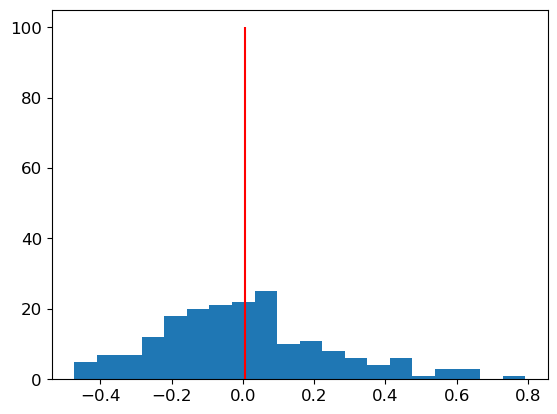

In [101]:
plt.hist(ns_catalog["ovdvalue"], bins=20)
plt.vlines([np.average(ns_catalog["ovdvalue"])], 0, 100, color='red')

### what is the expected overdensity?

In [102]:
from scipy.ndimage import gaussian_filter1d

z_bins = np.linspace(0.01, 0.54, 50)

z = np.array(ns_catalog["z"])
hist, edges = np.histogram(z, bins=54, range=[0.00, 0.54], density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(hist, sigma=0.1)

# normalize
nz /= np.trapz(nz, z_centers)

# GENERATE A RANDOM SOURCE FIELD 
rand_dat_ratio = 200
N_rand = rand_dat_ratio * ns_catalog.z.size
print(ns_catalog.z.size)

cdf = np.cumsum(nz)
cdf /= cdf[-1]

def sample_z(N):
    u = np.random.rand(N)
    return np.interp(u, cdf, z_centers)

z_rand = sample_z(N_rand)

190


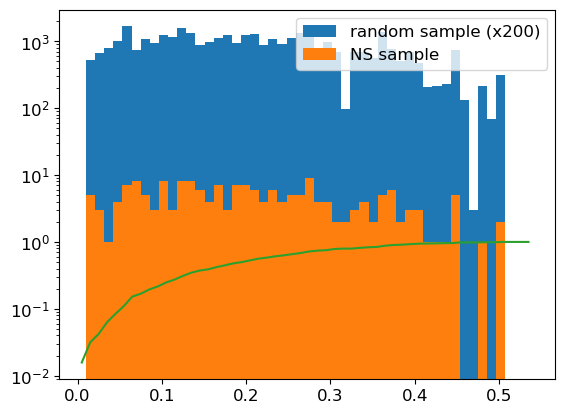

In [103]:
plt.hist(z_rand, bins=z_bins, label=f'random sample (x{rand_dat_ratio})')
plt.hist(ns_catalog.z, bins=z_bins, label='NS sample')
plt.plot(z_centers, cdf)
plt.legend()
plt.yscale('log')

In [104]:
# distributing random sources in the sky

mask = np.load('./galcats/2mass/2mass_mask.npy')

prob = mask.astype(float)
prob /= prob.sum()   # normalize

# draw pixel indices
npix = len(mask)
pix_rand = np.random.choice(np.arange(npix), size=N_rand, p=prob)

# convert to angles
theta_rand, phi_rand = hp.pix2ang(nside, pix_rand)

# to ra-dec
ra_rand = np.rad2deg(phi_rand)
dec_rand = 90 - np.rad2deg(theta_rand)

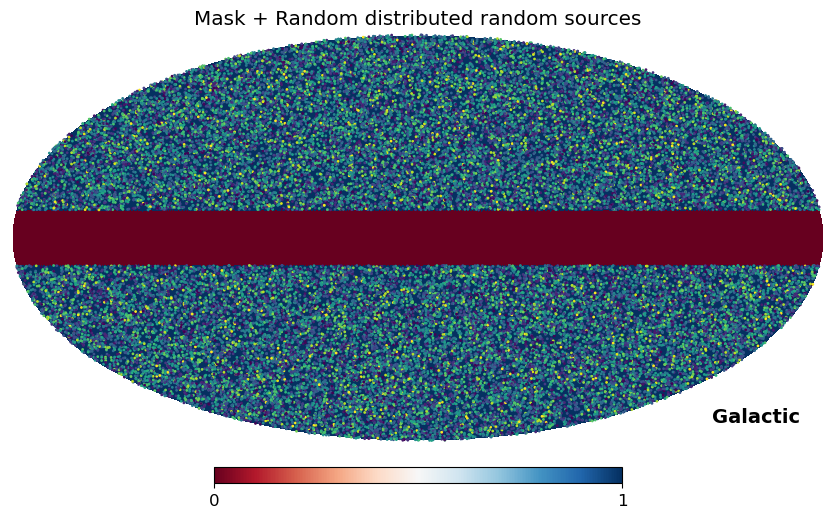

In [105]:
# sanity check of the randomly distributed sources
hp.mollview(mask, title="Mask + Random distributed random sources", rot=(180, 0, 0), cmap='RdBu', coord=['C', 'G'])
hp.projscatter(theta_rand, phi_rand, s=1, c=z_rand, coord='C')
plt.show()

In [106]:
rand_cat = pd.DataFrame(np.array([ra_rand, theta_rand, z_rand]).T, columns=["RA", "Dec", "z"])
rand_cat.head()

,RA,Dec,z
0,261.914062,1.403348,0.271658
1,333.984375,1.828859,0.216971
2,132.804878,0.806264,0.105498
3,31.289062,0.947970,0.138235
4,285.810811,2.417844,0.340658


In [107]:
rand_cat = rand_cat.sort_values(by="z")

pixs_r = hp.ang2pix(nside, theta=np.pi/2 - np.deg2rad(rand_cat["Dec"]), phi=np.deg2rad(rand_cat["RA"]))

zpx_ns_r, pxz_ns_r = np.meshgrid(z_grid, pixs_r, indexing='ij')
weights_r = zpx_ns_r < np.array(rand_cat["z"])
values_r = zp_interpolator((zpx_ns_r, pxz_ns_r )) * weights_r

In [108]:
rand_cat["ovdvalue"] = np.trapz(values_r, z_grid, axis=0) / rand_cat["z"]

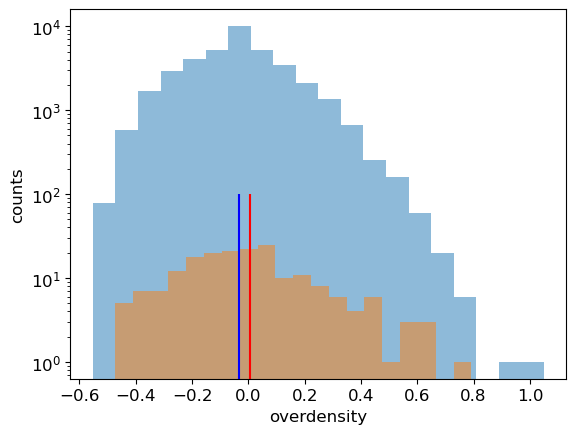

In [109]:
plt.hist(rand_cat["ovdvalue"], bins=20, alpha=0.5)
plt.hist(ns_catalog["ovdvalue"], bins=20, alpha=0.5)
plt.vlines([np.average(rand_cat["ovdvalue"]), np.average(ns_catalog["ovdvalue"])], 0, 100, colors=['blue', 'red'])
plt.yscale('log')
plt.xlabel("overdensity")
plt.ylabel("counts")
plt.show()

### voidiness?

In [110]:
ns_cat_v = np.trapz(np.clip(values, a_min=-1.0, a_max=1.0), z_grid, axis=0) / ns_catalog["z"]
rand_cat_v = np.trapz(np.clip(values_r, a_min=-1.0, a_max=1.0), z_grid, axis=0) / rand_cat["z"]

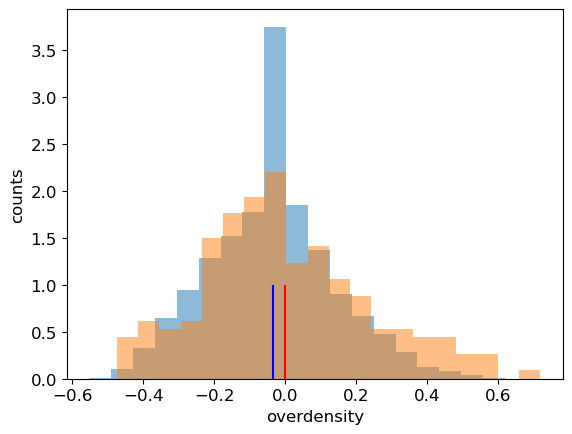

In [111]:
plt.hist(rand_cat_v, bins=20, alpha=0.5, density=True)
plt.hist(ns_cat_v, bins=20, alpha=0.5, density=True)
plt.vlines([np.average(rand_cat_v), np.average(ns_cat_v)], 0, 1, colors=['blue', 'red'])
# plt.yscale('log')
plt.xlabel("overdensity")
plt.ylabel("counts")
plt.show()